# Support Vector Machine (SVM) Classification Workflow

## Dataset Selection and Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset_url = 'https://raw.githubusercontent.com/datasets/breast-cancer/refs/heads/main/data/breast-cancer.csv'


df = pd.read_csv(dataset_url)
display(df.head())

,age,mefalsepause,tumor-size,inv-falsedes,falsede-caps,deg-malig,breast,breast-quad,irradiat,class
0,40-49,premefalse,15-19,0-2,True,3,right,left_up,False,recurrence-events
1,50-59,ge40,15-19,0-2,False,1,right,central,False,false-recurrence-events
2,50-59,ge40,35-39,0-2,False,2,left,left_low,False,recurrence-events
3,40-49,premefalse,35-39,0-2,True,3,right,left_low,True,false-recurrence-events
4,40-49,premefalse,30-34,3-5,True,2,left,right_up,False,recurrence-events


In [ ]:
# Display general information about the DataFrame
X = df.drop('class', axis=1)

print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           272 non-null    object
 1   mefalsepause  272 non-null    object
 2   tumor-size    272 non-null    object
 3   inv-falsedes  272 non-null    object
 4   falsede-caps  264 non-null    object
 5   deg-malig     272 non-null    int64 
 6   breast        272 non-null    object
 7   breast-quad   271 non-null    object
 8   irradiat      272 non-null    bool  
 9   class         272 non-null    object
dtypes: bool(1), int64(1), object(8)
memory usage: 19.5+ KB


## Data Preprocessing
### Handling Missing Values

In [ ]:
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


Missing values per column:
falsede-caps    8
breast-quad     1
dtype: int64


In [ ]:
# Display value counts for columns with missing values to decide on imputation strategy
print("\nValue counts for 'falsede-caps':")
print(df['falsede-caps'].value_counts(dropna=False))

print("\nValue counts for 'breast-quad':")
print(df['breast-quad'].value_counts(dropna=False))


Value counts for 'falsede-caps':
falsede-caps
False    209
True      55
NaN        8
Name: count, dtype: int64

Value counts for 'breast-quad':
breast-quad
left_low     103
left_up       92
right_up      32
right_low     24
central       20
NaN            1
Name: count, dtype: int64


In [ ]:
# Handling Missing Values
mode_falsede_caps = df['falsede-caps'].mode()[0]
df['falsede-caps'].fillna(mode_falsede_caps, inplace=True)

mode_breast_quad = df['breast-quad'].mode()[0]
df['breast-quad'].fillna(mode_breast_quad, inplace=True)


print("\nMissing values after imputation:")
print(df[['falsede-caps', 'breast-quad']].isnull().sum())


Missing values after imputation:
falsede-caps    0
breast-quad     0
dtype: int64


/tmp/ipykernel_5279/4088327147.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['falsede-caps'].fillna(mode_falsede_caps, inplace=True)
/tmp/ipykernel_5279/4088327147.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['falsede-caps'].fillna(mode_falsede_caps, inplace=True)
/tmp/ipykernel_5279/40883271

### Encoding Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

if 'class' in categorical_cols:
    categorical_cols.remove('class')

print("Categorical columns identified for encoding (excluding target 'class'):", categorical_cols)

print("\nUnique values for categorical features:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")

print(f"  class (target): {df['class'].unique()}")


Categorical columns identified for encoding (excluding target 'class'): ['age', 'mefalsepause', 'tumor-size', 'inv-falsedes', 'falsede-caps', 'breast', 'breast-quad', 'irradiat']

Unique values for categorical features:
  age: ['40-49' '50-59' '60-69' '30-39' '70-79' '20-29']
  mefalsepause: ['premefalse' 'ge40' 'lt40']
  tumor-size: ['15-19' '35-39' '30-34' '25-29' '40-44' '10-14' '0-4' '20-24' '45-49'
 '50-54' '5-9']
  inv-falsedes: ['0-2' '3-5' '15-17' '6-8' '9-11' '24-26' '12-14']
  falsede-caps: [ True False]
  breast: ['right' 'left']
  breast-quad: ['left_up' 'central' 'left_low' 'right_up' 'right_low']
  irradiat: [False  True]
  class (target): ['recurrence-events' 'false-recurrence-events']


In [ ]:
binary_cols = ['irradiat', 'falsede-caps', 'breast']
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Label encoded '{col}': {le.classes_} -> {df[col].unique()}")

# Encode the target variable 'class'
le_class = LabelEncoder()
df['class'] = le_class.fit_transform(df['class'])
print(f"Label encoded 'class': {le_class.classes_} -> {df['class'].unique()}")


onehot_cols = [col for col in categorical_cols if col not in binary_cols]

print("\nColumns to be One-Hot Encoded:", onehot_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols)
    ],
    remainder='passthrough'
)

df_encoded = preprocessor.fit_transform(df)

onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(onehot_cols)

remainder_cols = [col for col in df.columns if col not in onehot_cols]


df = pd.DataFrame(df_encoded, columns=list(onehot_feature_names) + remainder_cols)

print("\nDataFrame after encoding:")
display(df.head())
print("Shape after encoding:", df.shape)
print("Data types after encoding:")
print(df.info())

Label encoded 'irradiat': [False  True] -> [0 1]
Label encoded 'falsede-caps': [False  True] -> [1 0]
Label encoded 'breast': ['left' 'right'] -> [1 0]
Label encoded 'class': ['false-recurrence-events' 'recurrence-events'] -> [1 0]

Columns to be One-Hot Encoded: ['age', 'mefalsepause', 'tumor-size', 'inv-falsedes', 'breast-quad']

DataFrame after encoding:


,age_20-29,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_ge40,mefalsepause_lt40,mefalsepause_premefalse,tumor-size_0-4,...,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,falsede-caps,deg-malig,breast,irradiat,class
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,1.0


Shape after encoding: (272, 37)
Data types after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_20-29                272 non-null    float64
 1   age_30-39                272 non-null    float64
 2   age_40-49                272 non-null    float64
 3   age_50-59                272 non-null    float64
 4   age_60-69                272 non-null    float64
 5   age_70-79                272 non-null    float64
 6   mefalsepause_ge40        272 non-null    float64
 7   mefalsepause_lt40        272 non-null    float64
 8   mefalsepause_premefalse  272 non-null    float64
 9   tumor-size_0-4           272 non-null    float64
 10  tumor-size_10-14         272 non-null    float64
 11  tumor-size_15-19         272 non-null    float64
 12  tumor-size_20-24         272 non-null    float64
 13  tumor-size_25-29     

###  Analyze Numerical Features and Scaling

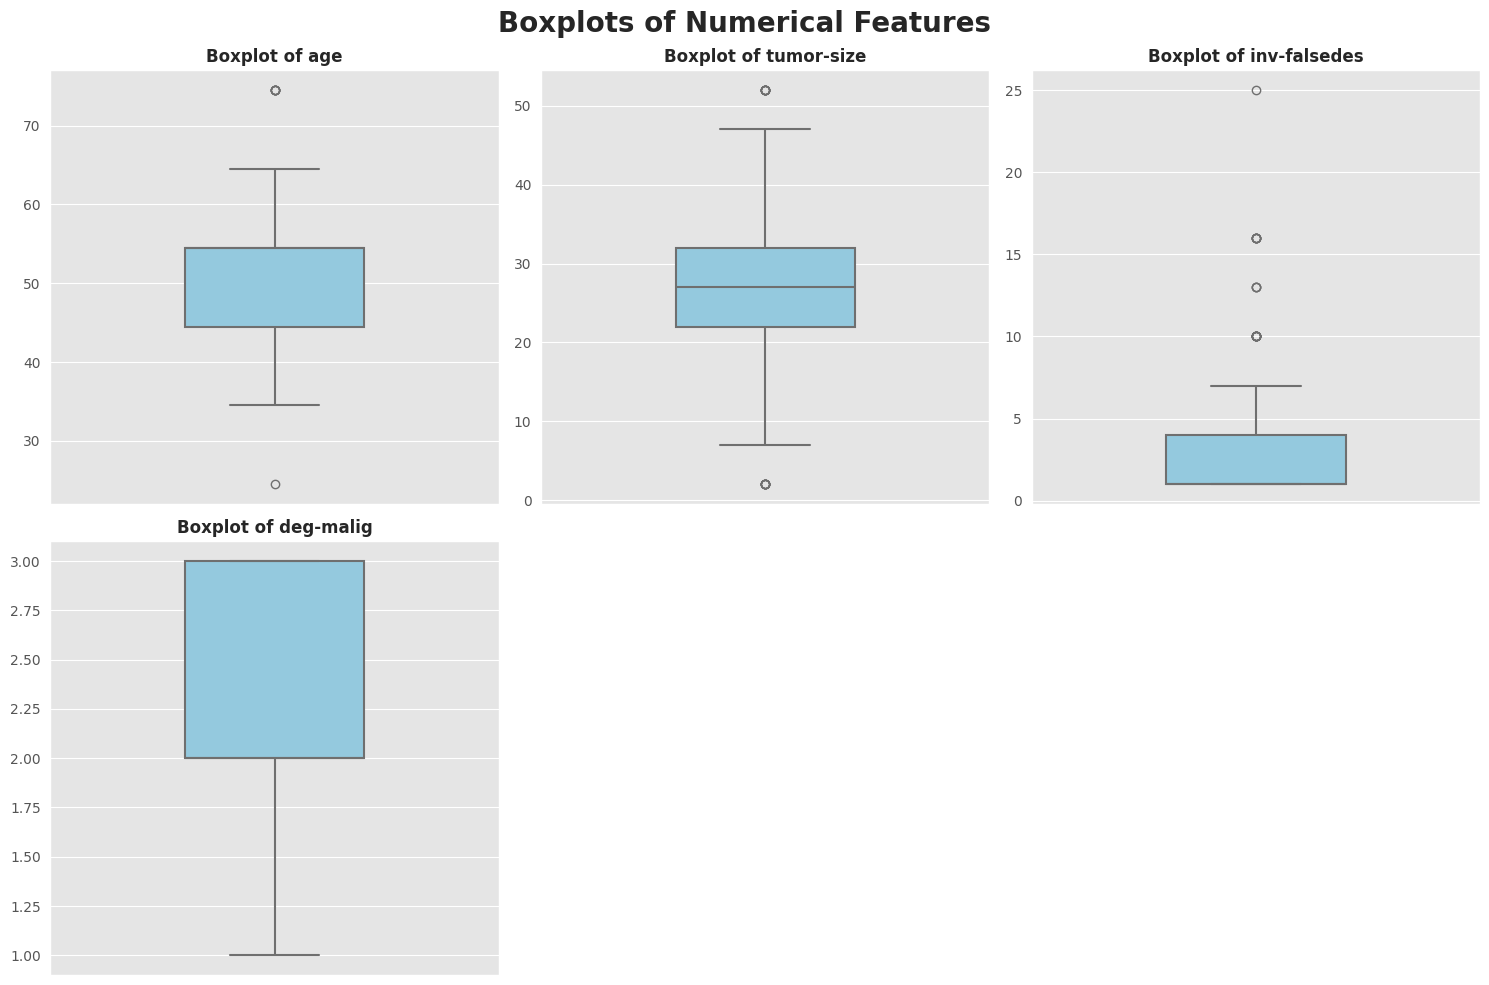

In [ ]:
def convert_range_to_mid(value):

    if pd.isna(value) or value == '?':
        return None

    parts = value.split('-')

    return (int(parts[0]) + int(parts[1])) / 2



X['age'] = X['age'].apply(convert_range_to_mid)

X['tumor-size'] = X['tumor-size'].apply(convert_range_to_mid)

X['inv-falsedes'] = X['inv-falsedes'].apply(convert_range_to_mid)

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns


plt.style.use('ggplot')

# Create figure
plt.figure(figsize=(15, 10))

rows = (len(numerical_cols) + 2) // 3

for i, col in enumerate(numerical_cols):

    plt.subplot(rows, 3, i + 1)

    sns.boxplot(
        y=X[col],
        color='skyblue',
        width=0.4,
        linewidth=1.5
    )

    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.xlabel('')

# Main title
plt.suptitle(
    'Boxplots of Numerical Features',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

###  Normalize/Standardize Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Redefine X and y using the fully encoded 'df' (which is df_encoded from previous steps)
X = df.drop('class', axis=1)
y = df['class']

# Apply StandardScaler to the features
schaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for easier handling, retaining column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

print("Descriptive statistics of scaled features:")
display(X_scaled_df.describe())

,age_20-29,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_ge40,mefalsepause_lt40,mefalsepause_premefalse,tumor-size_0-4,...,inv-falsedes_9-11,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,falsede-caps,deg-malig,breast,irradiat
0,-0.060746,-0.377964,1.458231,-0.709057,-0.491944,-0.150188,-0.901850,-0.162527,0.949788,-0.174078,...,-0.195366,-0.281718,-0.786796,1.398757,-0.311086,-0.365148,1.986317,1.28,1.052866,-0.57169
1,-0.060746,-0.377964,-0.685763,1.410323,-0.491944,-0.150188,1.108832,-0.162527,-1.052866,-0.174078,...,-0.195366,3.549648,-0.786796,-0.714920,-0.311086,-0.365148,-0.503444,-1.44,1.052866,-0.57169
2,-0.060746,-0.377964,-0.685763,1.410323,-0.491944,-0.150188,1.108832,-0.162527,-1.052866,-0.174078,...,-0.195366,-0.281718,1.270978,-0.714920,-0.311086,-0.365148,-0.503444,-0.08,-0.949788,-0.57169
3,-0.060746,-0.377964,1.458231,-0.709057,-0.491944,-0.150188,-0.901850,-0.162527,0.949788,-0.174078,...,-0.195366,-0.281718,1.270978,-0.714920,-0.311086,-0.365148,1.986317,1.28,1.052866,1.74920
4,-0.060746,-0.377964,1.458231,-0.709057,-0.491944,-0.150188,-0.901850,-0.162527,0.949788,-0.174078,...,-0.195366,-0.281718,-0.786796,-0.714920,-0.311086,2.738613,1.986317,-0.08,-0.949788,-0.57169


Descriptive statistics of scaled features:


,age_20-29,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,mefalsepause_ge40,mefalsepause_lt40,mefalsepause_premefalse,tumor-size_0-4,...,inv-falsedes_9-11,breast-quad_central,breast-quad_left_low,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,falsede-caps,deg-malig,breast,irradiat
count,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,272.000000,2.720000e+02,2.720000e+02,272.000000,...,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02,2.720000e+02
mean,1.306145e-17,-4.571507e-17,4.571507e-17,9.143013e-17,3.102094e-17,-6.530724e-18,0.000000,1.306145e-17,-3.591898e-17,0.000000,...,5.714383e-17,-5.877651e-17,9.796086e-18,-1.632681e-17,5.224579e-17,-9.796086e-18,-1.306145e-17,2.285753e-16,3.918434e-17,5.224579e-17
std,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843,1.001843e+00,1.001843e+00,1.001843,...,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00,1.001843e+00
min,-6.074567e-02,-3.779645e-01,-6.857625e-01,-7.090574e-01,-4.919442e-01,-1.501879e-01,-0.901850,-1.625272e-01,-1.052866e+00,-0.174078,...,-1.953662e-01,-2.817181e-01,-7.867958e-01,-7.149204e-01,-3.110855e-01,-3.651484e-01,-5.034444e-01,-1.440000e+00,-9.497883e-01,-5.716898e-01
25%,-6.074567e-02,-3.779645e-01,-6.857625e-01,-7.090574e-01,-4.919442e-01,-1.501879e-01,-0.901850,-1.625272e-01,-1.052866e+00,-0.174078,...,-1.953662e-01,-2.817181e-01,-7.867958e-01,-7.149204e-01,-3.110855e-01,-3.651484e-01,-5.034444e-01,-8.000000e-02,-9.497883e-01,-5.716898e-01
50%,-6.074567e-02,-3.779645e-01,-6.857625e-01,-7.090574e-01,-4.919442e-01,-1.501879e-01,-0.901850,-1.625272e-01,9.497883e-01,-0.174078,...,-1.953662e-01,-2.817181e-01,-7.867958e-01,-7.149204e-01,-3.110855e-01,-3.651484e-01,-5.034444e-01,-8.000000e-02,-9.497883e-01,-5.716898e-01
75%,-6.074567e-02,-3.779645e-01,1.458231e+00,1.410323e+00,-4.919442e-01,-1.501879e-01,1.108832,-1.625272e-01,9.497883e-01,-0.174078,...,-1.953662e-01,-2.817181e-01,1.270978e+00,1.398757e+00,-3.110855e-01,-3.651484e-01,-5.034444e-01,1.280000e+00,1.052866e+00,-5.716898e-01
max,1.646208e+01,2.645751e+00,1.458231e+00,1.410323e+00,2.032751e+00,6.658328e+00,1.108832,6.152816e+00,9.497883e-01,5.744563,...,5.118594e+00,3.549648e+00,1.270978e+00,1.398757e+00,3.214550e+00,2.738613e+00,1.986317e+00,1.280000e+00,1.052866e+00,1.749200e+00


### Split into Train/Test/Validation Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and temporary sets (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Data split into training, validation, and test sets successfully!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Verify stratification (optional, but good practice)
print("\nTarget distribution in original dataset:\n", y.value_counts(normalize=True))
print("Target distribution in training set:\n", y_train.value_counts(normalize=True))
print("Target distribution in validation set:\n", y_val.value_counts(normalize=True))
print("Target distribution in test set:\n", y_test.value_counts(normalize=True))

Data split into training, validation, and test sets successfully!
X_train shape: (190, 36), y_train shape: (190,)
X_val shape: (41, 36), y_val shape: (41,)
X_test shape: (41, 36), y_test shape: (41,)

Target distribution in original dataset:
 class
0.0    0.702206
1.0    0.297794
Name: proportion, dtype: float64
Target distribution in training set:
 class
0.0    0.7
1.0    0.3
Name: proportion, dtype: float64
Target distribution in validation set:
 class
0.0    0.707317
1.0    0.292683
Name: proportion, dtype: float64
Target distribution in test set:
 class
0.0    0.707317
1.0    0.292683
Name: proportion, dtype: float64


## Model Training

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42, probability=True) # probability=True is needed for ROC curve and probability scores

print("SVM model initialized:")
print(svm_model)

SVM model initialized:
SVC(probability=True, random_state=42)


## Hyperparameter Tuning (kernel, C, gamma, degree)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np

# Define the parameter grid for SVC
param_grid = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]},
    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'degree': [2, 3, 4], 'gamma': [0.001, 0.01, 0.1, 1]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]},
    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]}
]


# Combine training and validation sets for GridSearchCV if we want to tune on both
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Initialize SVC model for grid search
svm = SVC(random_state=42, probability=True)

# Setup GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

print("Starting GridSearchCV for hyperparameter tuning...")
# Fit GridSearchCV on the combined training and validation data
grid_search.fit(X_train_val, y_train_val)

print("Hyperparameter tuning complete.")

# Display best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))

# Store the best model
best_svm_model = grid_search.best_estimator_
print("\nBest SVM model stored.")

Starting GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 84 candidates, totalling 420 fits
Hyperparameter tuning complete.

Best parameters found:  {'C': 100, 'degree': 4, 'gamma': 0.01, 'kernel': 'poly'}
Best cross-validation accuracy: 0.71

Best SVM model stored.


### Evaluation Metrics: Accuracy, Precision, Recall, F1-score, AUC

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best model
y_pred = best_svm_model.predict(X_test)
y_prob = best_svm_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("### Model Evaluation on Test Set ###")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### Model Evaluation on Test Set ###
Accuracy: 0.6585
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
AUC: 0.6695

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.93      0.79        29
         1.0       0.00      0.00      0.00        12

    accuracy                           0.66        41
   macro avg       0.35      0.47      0.40        41
weighted avg       0.49      0.66      0.56        41



### Confusion Matrix

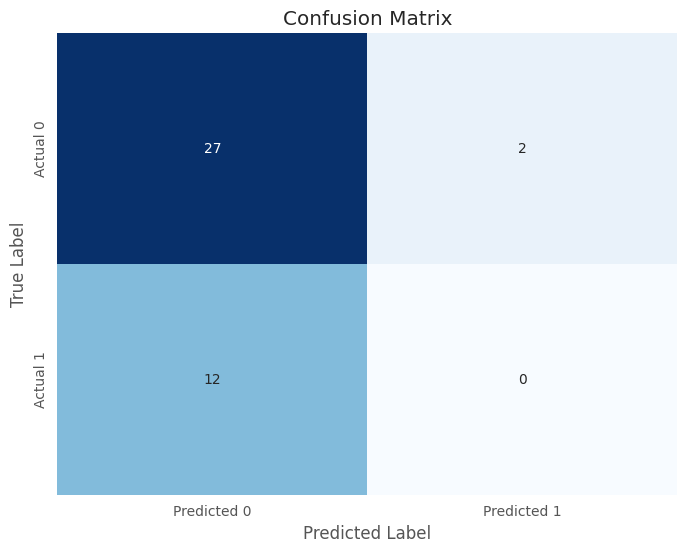

In [ ]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###  ROC Curve

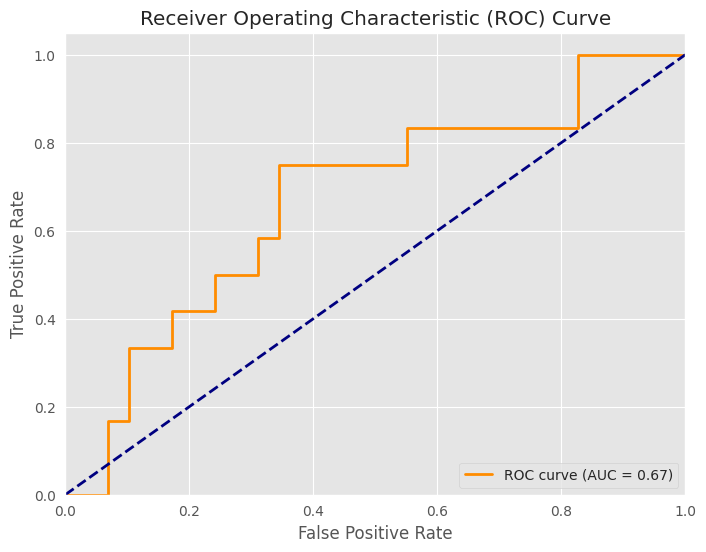

In [ ]:
# Generate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Sample Predictions (Actual vs Predicted + Probability Scores)

In [ ]:
# Create a DataFrame to display sample predictions
sample_predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability_0': best_svm_model.predict_proba(X_test)[:, 0],
    'Probability_1': best_svm_model.predict_proba(X_test)[:, 1]
})

print("\nSample Predictions (Actual vs Predicted with Probability Scores):")
display(sample_predictions.head(10))


Sample Predictions (Actual vs Predicted with Probability Scores):


,Actual,Predicted,Probability_0,Probability_1
242,0.0,0.0,0.745340,0.254660
17,0.0,0.0,0.718544,0.281456
126,0.0,0.0,0.733110,0.266890
0,1.0,0.0,0.713941,0.286059
172,1.0,0.0,0.710022,0.289978
260,0.0,0.0,0.655102,0.344898
105,0.0,0.0,0.752642,0.247358
114,0.0,0.0,0.742351,0.257649
252,0.0,0.0,0.684277,0.315723
268,0.0,0.0,0.652614,0.347386


### 2D Classification Plot (if applicable)

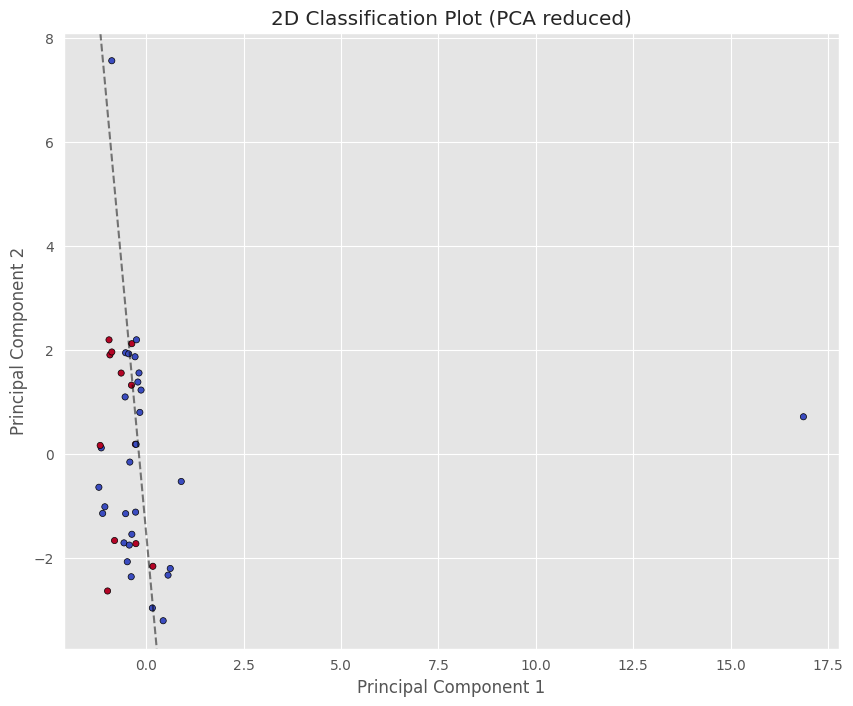

In [ ]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

svm_pca = SVC(kernel='linear', random_state=42)
svm_pca.fit(X_test_pca, y_test)

plt.figure(figsize=(10, 8))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', s=20, edgecolors='k')

# Plot the decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_pca.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

plt.title('2D Classification Plot (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()